In [56]:
import numpy as np
import argparse
import scipy.io
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from random import *
from pathlib import Path

plt.rcParams['font.size'] = 14


### read the data

In [2]:
# Read the MATLAB file
mat = scipy.io.loadmat('../ltpFR/ltpFR_lsa.mat')
lsa_data = mat['lsa']

In [3]:
print(lsa_data.shape)

(1638, 1638)


In [ ]:
""" Reference: https://github.com/nds113/seq2seq_hms """

def read_peers_data(files_dir='../ltpFR/'):

    ################
    #Extract session 1, young subjects data from PEERS

    #Download entire PEERS dataset from: http://memory.psych.upenn.edu/Data_Archive

    ############

    # PARAMETERS

    # select subjects
    all_subjects = range(63,301)
    subject_dir = os.path.join(files_dir, 'PEERS_older_adult_subject_list.txt')
    with open(subject_dir) as f:
        content = f.readlines()
        content = [x.split() for x in content]
    subjects_old = [int(x[0]) for x in content]
    subjects_young = [x for x in all_subjects if x not in subjects_old]

    # options: 1. all_subjects 2. subjects_old 3. subjects_young
    subjects = subjects_young

    # other parameters
    LL = 16

    # DATA
    recalls_sp = []
    recalls = []
    presents = []
    presented_words = []
    recalled_words = []
    sessionlengths = []
    listlengths = []
    subjs = []
    subjs_list = [] # re-numbered subjects starting from zero - consistent with 'subjs'
    for s, subj in enumerate(subjects):
        subjs_list.append(s)
        #sessionlength = []
        listlength = []
        length = 0
        for session in [1,2,3,4,5,6]: # excluding the first section which is a practice section
            # Specify data file directory - 3 digits for each subj ID
            if len(str(subj))<3:
                parent_dir = os.path.join(files_dir,'LTP0' + str(subj),'session_' + str(session))
            else:
                parent_dir = os.path.join(files_dir,'LTP' + str(subj),'session_' + str(session))
            data_dir1 = parent_dir + '/session.log'
            my_file1 = Path(data_dir1)


            # Load presentation details
            if my_file1.is_file():
                data_dir1 = parent_dir + '/session.log'
                with open(data_dir1) as f:
                    content = f.readlines()
                    content = [x.split() for x in content]
                pre_list = 0
                position = 0
                dics = []
                presented = []
                present = []
                for i in range(len(content)):
                    if content[i][2] == 'FR_PRES': # record only stimuli in the encoding stage
                        current_list = int(content[i][3])
                        item = int(content[i][5])
                        word = content[i][4]
                        presented.append(word)
                        dics.append([item,current_list,position]) # create dictionary of word ID, list number, serial position
                        if current_list != pre_list:
                            # switch to a new list
                            position = 0
                            presented_words.append(presented)
                            presents.append(present)
                            presented = []
                            present = []
                        present.append([subj,session,item,current_list,position,word]) #subj, session, item ID, list number, serial position, word
                        pre_list = current_list
                        position = position + 1
                presented_words.append(presented)  
                presents.append(present)

                data_dir = parent_dir + '/15.par'
                my_file = Path(data_dir)
                if position == LL and my_file.is_file(): # two kinds of trials (3 or 16 items during encoding), only take trials with 16 items encoded; only take sessions with 16 lists
                    listlength.append(position)

                    # IMMEDIATE FREE RECALL
                    for listno in range(16): # every selected session has 16 lists
                        data_dir3 = parent_dir + '/' + str(listno)+ '.par'
                        my_file3 = Path(data_dir3)
                        if my_file3.is_file():
                            length = length + 1
                            recall = []
                            recall_sp = []
                            subjs.append(s)

                            with open(data_dir3) as f:
                                content = f.readlines()
                                content = [x.split() for x in content]
                            lasttime = 0
                            words = []
                            for i in range(len(content)):
                                item = int(content[i][1])
                                word = content[i][2]
                                temp = [x for x in dics if x[0] == item]
                                currenttime = int(content[i][0])
                                RT = (currenttime - lasttime)/1000
                                lasttime = currenttime
                                #words.append(word)
                                if len(temp)>0:
                                    recall_sp.append(temp[0][2])
                                    words.append(word)
                                    recall.append([subj,session,item,temp[0][1],temp[0][2],word]) #subj, session, item ID, list number, serial position, word
                                else:
                                    recall_sp.append(-1)
                                    recall.append([subj,session,item,-1,-1,word]) #subj, session, item ID, list number, serial position, word

                            recalled_words.append(words)
                            recalls.append(recall)
                            recalls_sp.append(recall_sp)
        listlengths.append(listlength)
        sessionlengths.append(length)

    return recalls, recalls_sp, listlengths, sessionlengths, subjects, subjs, presented_words, recalled_words, presents

def build_peers_vocabulary(dir, output_file, include_errors=False):

    recalls, _, _, _, _, _, _, _, presents = read_peers_data(dir)

    # Build initial vocabulary from PEERS presented words
    peers_vocabulary = {}
    for session in presents:
        for word in session:
            peers_vocabulary[word[-1]] = word[2]
    
    if include_errors:
        # Sort vocab by word index
        sorted_tuples_desc = sorted(peers_vocabulary.items(), key=lambda item: item[1])
        sorted_dict_desc = dict(sorted_tuples_desc)

        # Collect un-presented words from recalls (omit extraneous tokens)
        unseen_words = []
        for session in recalls:
            for word in session:
                if word[-1] not in peers_vocabulary and word[-1] != 'VV' and '?' not in word[-1] and len(word[-1]) > 1:
                    unseen_words.append(word[-1])

        # Append un-presented word to vocabulary with incremented vocab indices
        for i, word in enumerate(unseen_words):
            peers_vocabulary[word] = i+len(sorted_dict_desc)+1

    #peers_vocabulary['<NULL>'] = 0
    with open(output_file, 'w') as f:
        json.dump(peers_vocabulary, f, indent=2)

def load_cached_vocabulary(cached_vocab_file):

    # # Get the directory where the current file (main_module.py) is located
    # current_directory = os.path.dirname(os.path.abspath(__file__))

    # # Build the path to config.json
    # json_path = os.path.join(current_directory, cached_vocab_file)

    json_path = cached_vocab_file
    
    with open(json_path, 'r') as f:
        json_data = json.load(f)

    # vocab = list(json_data.keys())
    vocab = json_data

    return vocab

In [5]:
raw_data_dir = '../ltpFR/'
build_peers_vocabulary(raw_data_dir, './human_data/peers_vocab.json')

In [6]:
recalls, recalls_sp, listlengths, sessionlengths, subjects, subjs, presented_words, recalled_words, presents = read_peers_data(raw_data_dir)

In [7]:
print(len(recalls))
print(len(presents))
print(len(recalls_sp))
print(len(listlengths))
print(len(sessionlengths))
print(len(subjects))
print(len(subjs))
print(len(presented_words))
print(len(recalled_words))

17341
17369
17341
200
200
200
17341
17369
17341


In [8]:
print(recalls[0])
print(presents[0])
print(recalls[1])
print(presents[1])
# print(recalls_sp[0])
# print(listlengths[0])
# print(sessionlengths[0])
# print(subjects[0])
# print(subjs[0])
# print(presented_words[0])
# print(recalled_words[0])


[[63, 1, 1279, 0, 15, 'SHEET'], [63, 1, 291, 0, 13, 'CHEMICAL'], [63, 1, 1618, 0, 6, 'WITNESS'], [63, 1, 203, 0, 1, 'BUTCHER'], [63, 1, 913, 0, 2, 'MONUMENT'], [63, 1, 737, 0, 0, 'INFANT'], [63, 1, 1258, 0, 9, 'SCULPTURE']]
[[63, 1, 737, 0, 0, 'INFANT'], [63, 1, 203, 0, 1, 'BUTCHER'], [63, 1, 913, 0, 2, 'MONUMENT'], [63, 1, 382, 0, 3, 'CORPORATION'], [63, 1, 31, 0, 4, 'APE'], [63, 1, 733, 0, 5, 'IDOL'], [63, 1, 1618, 0, 6, 'WITNESS'], [63, 1, 391, 0, 7, 'COURT'], [63, 1, 1171, 0, 8, 'RAZOR'], [63, 1, 1258, 0, 9, 'SCULPTURE'], [63, 1, 931, 0, 10, 'MULE'], [63, 1, 1221, 0, 11, 'SADDLE'], [63, 1, 1372, 0, 12, 'STAPLER'], [63, 1, 291, 0, 13, 'CHEMICAL'], [63, 1, 1550, 0, 14, 'VAULT'], [63, 1, 1279, 0, 15, 'SHEET']]
[[63, 1, 1215, 1, 15, 'RUG'], [63, 1, 1608, 1, 13, 'WIDOW'], [63, 1, 1450, 1, 12, 'TERMINAL'], [63, 1, 255, 1, 1, 'CASKET']]
[[63, 1, 536, 1, 0, 'ENGINEER'], [63, 1, 255, 1, 1, 'CASKET'], [63, 1, 609, 1, 2, 'FROST'], [63, 1, 577, 1, 3, 'FLEA'], [63, 1, 1112, 1, 4, 'POSSUM'], [63

In [9]:
recalls_data = {}

error_num = 0
for i in range(len(recalls)):
    if len(recalls[i]) == 0:
        continue
    first_correct_idx = 0
    error = False
    while recalls[i][first_correct_idx][2] == -1:
        first_correct_idx += 1
        if first_correct_idx >= len(recalls[i]):
            print(recalls[i])
            print('error finding the first correct recall, subject: {}, session: {}, list number: {}'.format(recalls[i][0][0], recalls[i][0][1], recalls[i][0][3]))
            error = True
            break
    if error:
        error_num += 1
        continue
    key = (recalls[i][first_correct_idx][0], recalls[i][first_correct_idx][1], recalls[i][first_correct_idx][3])
    recalls_data[key] = i

print(error_num)

[[96, 4, -1, -1, -1, 'VV']]
error finding the first correct recall, subject: 96, session: 4, list number: -1
[[109, 5, -1, -1, -1, 'VV']]
error finding the first correct recall, subject: 109, session: 5, list number: -1
[[190, 1, -1, -1, -1, 'VV']]
error finding the first correct recall, subject: 190, session: 1, list number: -1
[[190, 5, -1, -1, -1, 'VV']]
error finding the first correct recall, subject: 190, session: 5, list number: -1
4


In [10]:
presents_data = {}

error_num = 0
for i in range(len(presents)):
    if len(presents[i]) == 0:
        continue
    key = (presents[i][0][0], presents[i][0][1], presents[i][0][3])
    presents_data[key] = i

print(error_num)

0


In [11]:
vocab = load_cached_vocabulary('./human_data/peers_vocab.json')
print(vocab)

{'INFANT': 737, 'BUTCHER': 203, 'MONUMENT': 913, 'CORPORATION': 382, 'APE': 31, 'IDOL': 733, 'WITNESS': 1618, 'COURT': 391, 'RAZOR': 1171, 'SCULPTURE': 1258, 'MULE': 931, 'SADDLE': 1221, 'STAPLER': 1372, 'CHEMICAL': 291, 'VAULT': 1550, 'SHEET': 1279, 'ENGINEER': 536, 'CASKET': 255, 'FROST': 609, 'FLEA': 577, 'POSSUM': 1112, 'GERM': 632, 'LINEN': 825, 'KLEENEX': 782, 'WATERFALL': 1595, 'REEF': 1177, 'VELVET': 1555, 'COYOTE': 396, 'TERMINAL': 1450, 'WIDOW': 1608, 'CEILING': 265, 'RUG': 1215, 'SALESMAN': 1225, 'TECHNICIAN': 1443, 'CHISEL': 305, 'SNEAKER': 1334, 'MOLECULE': 905, 'BLUEPRINT': 142, 'CABIN': 211, 'ZEBRA': 1635, 'SHOVEL': 1295, 'STREAM': 1392, 'RANCH': 1166, 'CHEERLEADER': 288, 'PUZZLE': 1146, 'PIER': 1063, 'BEER': 114, 'BARTENDER': 92, 'GAUZE': 626, 'SCALPEL': 1243, 'CEMETERY': 269, 'CIRCUS': 311, 'CLERK': 321, 'CRADLE': 399, 'WHISKERS': 1605, 'GENTLEMAN': 631, 'POOL': 1103, 'TIDE': 1465, 'KING': 777, 'CELLAR': 267, 'ASSISTANT': 48, 'THRONE': 1461, 'MISTER': 901, 'BALCONY': 7

In [12]:
""" build the dataset """
dataset = {'subject': [], 'session': [], 'list number': [], 'presented words': [], 'recalled words': [], 'recall sequence position': []}

presented_idx = 0
error_num = 0
for key, i in recalls_data.items():
    if not key in presents_data or len(recalled_words[i]) == 0:
        error_num += 1
        continue
    presented_idx = presents_data[key]
    dataset['subject'].append(recalls[i][0][0])
    dataset['session'].append(recalls[i][0][1])
    dataset['list number'].append(recalls[i][0][3])
    dataset['presented words'].append(presented_words[presented_idx])
    dataset['recalled words'].append(recalled_words[i])
    # dataset['recall sequence position'].append(recalls_sp[i])
    sequence_positions = []
    if len(recalled_words[i]) > 0:
        presented_words_idx = []
        for j in range(len(presented_words[presented_idx])):
            presented_words_idx.append(vocab[presented_words[presented_idx][j]])
        recalled_words_idx = []
        for j in range(len(recalled_words[i])):
            recalled_words_idx.append(vocab[recalled_words[i][j]])
        # print(presented_words_idx, recalled_words_idx)
        presented_words_idx = np.array(presented_words_idx)
        recalled_words_idx = np.array(recalled_words_idx)
        for j in range(len(recalled_words[i])):
            sp = np.where(presented_words_idx == recalled_words_idx[j])
            if len(sp[0]) > 0:
                sequence_positions.append(sp[0][0])
            # else:
            #     sequence_positions.append(-1)
    dataset['recall sequence position'].append(sequence_positions)

print(error_num)


76


In [13]:
df = pd.DataFrame(dataset)
df.to_csv('peers_dataset.csv', index=False)

In [46]:
from scipy.stats import rankdata

def compute_crp(recall_sequence_positions):
    memory_num = 16
    results = np.zeros((memory_num, memory_num))
    for i in range(len(recall_sequence_positions)):
        for t in range(len(recall_sequence_positions[i]) - 1):
            position1 = recall_sequence_positions[i][t]
            position2 = recall_sequence_positions[i][t+1]
            if position1 != -1 and position2 != -1 and position1 < memory_num and position2 < memory_num:
                results[position1][position2] += 1

    # forward_asymmetry = np.sum(np.triu(results, k=1)) / np.sum(results)

    baseline_all_time = np.zeros((memory_num, memory_num*2-1))
    for i in range(memory_num):
        baseline_all_time[i, memory_num-1-i:memory_num*2-1-i] = np.ones(memory_num)
    baseline_all_time = np.sum(baseline_all_time, axis=0)
    baseline_all_time = baseline_all_time / np.sum(baseline_all_time)

    results_all_time = np.zeros((memory_num, memory_num*2-1))
    for i in range(memory_num):
        results_all_time[i, memory_num-1-i:memory_num*2-1-i] = results[i]
    results_all_time = np.sum(results_all_time, axis=0)

    midpoint = len(results_all_time) // 2
    forward_asymmetry = np.sum(results_all_time[midpoint+1:-2]) / np.sum(results_all_time[2:])

    # balance based on random recall probability
    average_times = np.concatenate((np.arange(1, memory_num+1),np.arange(memory_num-1, 0, -1)), axis=0)
    results_all_time = results_all_time / average_times
    results_all_time = results_all_time / np.sum(results_all_time)
    # results_all_time = results_all_time / np.sum(results_all_time)

    times_sum = np.expand_dims(np.sum(results, axis=1), axis=1)
    times_sum[times_sum == 0] = 1
    results = results / times_sum

    return forward_asymmetry, results_all_time


def compute_accuracy(recalled_words, presented_words):
    accuracy = 0
    for i in range(len(recalled_words)):
        for j in range(len(recalled_words[i])):
            if recalled_words[i][j] in presented_words[i]:
                accuracy += 1
    return accuracy / len(recalled_words) / 16


def compute_temporal_factor(recall_sequence_positions):
    memory_num = 16
    max_length = 16
    for i in range(len(recall_sequence_positions)):
        if len(recall_sequence_positions[i]) > max_length:
            max_length = len(recall_sequence_positions[i])
    results = np.zeros((len(recall_sequence_positions), max_length))
    results_mask = np.zeros((len(recall_sequence_positions), max_length))
    # print(np.max([max(recall_sequence_positions[i]) for i in range(len(recall_sequence_positions))]))
    for i in range(len(recall_sequence_positions)):
        if len(recall_sequence_positions[i]) == 0:
            continue
        recalled = np.zeros(max(recall_sequence_positions[i])+1, dtype=bool)
        for t in range(len(recall_sequence_positions[i]) - 1):
            # print("t:", t)
            position1 = recall_sequence_positions[i][t] 
            position2 = recall_sequence_positions[i][t+1]
            # print(position1, position2)
            # get a transition i->j that i and j are not wrong, not recalled and not the same
            if position1 != -1 and position2 != -1 and \
                not recalled[position1] and not recalled[position2]\
                    and not position1 == position2:
                results_mask[i][t+1] = 1
                recalled[recall_sequence_positions[i][t]] = True
                # possible next memory to recall (delete all recalled ones)
                possible_transitions = ~np.isin(np.arange(memory_num), recall_sequence_positions[i][:t+1])
                # find the actual transition in the possible transitions
                actual_transition = np.arange(memory_num)[possible_transitions] == recall_sequence_positions[i][t+1]
                # compute the distance of each possible transition to the current recalled item
                possible_temporal_transitions = np.arange(memory_num)[possible_transitions] - position1
                if len(possible_temporal_transitions) > 1 and np.any(actual_transition):
                    # compute the rank number of all the possible transitions (the farer the transition is, the lower the rank is)
                    ranks = rankdata(-np.abs(possible_temporal_transitions))
                    value = (ranks[actual_transition] - 1) / (len(ranks) - 1)
                    results[i][t+1] = value[0]
    return np.mean(results[results_mask == 1])


In [18]:
# Group data by subject and convert recall sequence position to a list for each subject
df_grouped = df.groupby('subject').agg({
    'session': list,
    'list number': list,
    'presented words': list,
    'recalled words': list,
    'recall sequence position': list
}).reset_index()

In [47]:
accuracies, temporal_factors, forward_asymmetries = [], [], []
crp_results = []
for i in range(len(df_grouped)):
    accuracy = compute_accuracy(df_grouped['recalled words'][i], df_grouped['presented words'][i])
    temporal_factor = compute_temporal_factor(df_grouped['recall sequence position'][i])
    forward_asymmetry, crp = compute_crp(df_grouped['recall sequence position'][i])
    accuracies.append(accuracy)
    temporal_factors.append(temporal_factor)
    forward_asymmetries.append(forward_asymmetry)
    crp_results.append(crp)



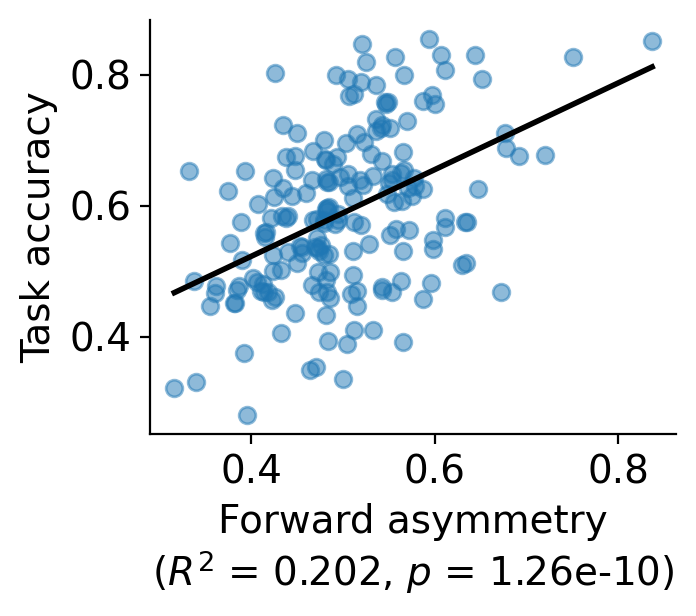

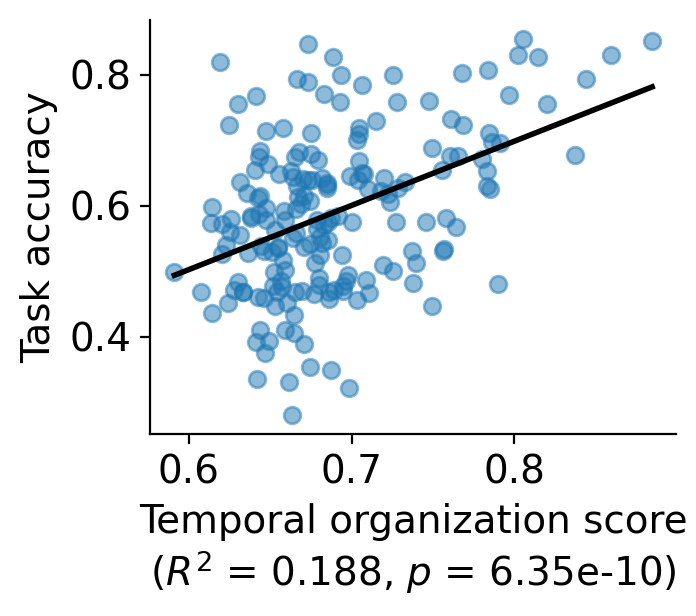

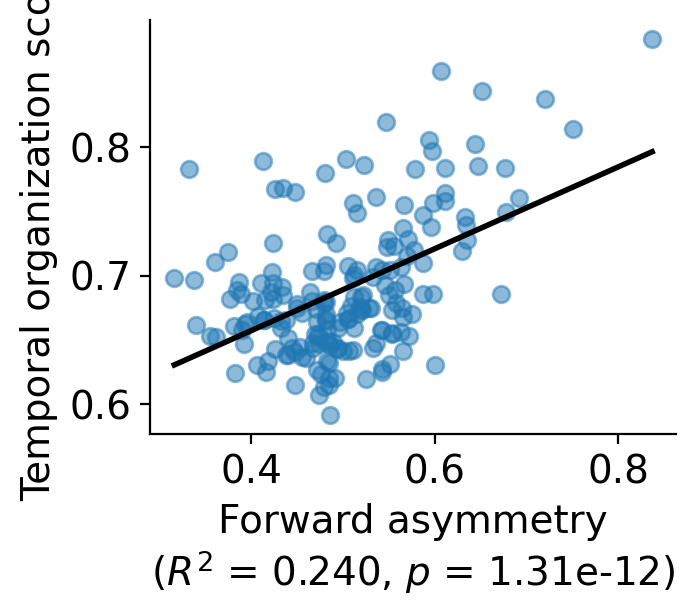

In [63]:
from sklearn.linear_model import LinearRegression
import numpy as np

from scipy.stats import linregress

# Add fitted line to "forward asymmetry vs accuracy" plot
plt.figure(figsize=(3.7, 3.3), dpi=200)
plt.scatter(forward_asymmetries, accuracies, alpha=0.5)
plt.xlabel('Forward asymmetry')

# Fit line using scikit-learn and calculate R^2 and p-value
X = np.array(forward_asymmetries)
y = np.array(accuracies)
r2, pval = None, None
if len(X) > 1:
    reg = LinearRegression().fit(X.reshape(-1, 1), y)
    x_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = reg.predict(x_pred)
    plt.plot(x_pred, y_pred, color="black", linewidth=2)

    # Compute R^2 and p-value using scipy
    slope, intercept, r_value, p_value, std_err = linregress(X, y)
    r2 = r_value ** 2
    pval = p_value

if r2 is not None and pval is not None:
    plt.ylabel('Task accuracy')
    # Add as a second line below x label
    plt.gca().set_xlabel("Forward asymmetry\n($R^2$ = {:.3f}, $p$ = {:.3g})".format(r2, pval))
else:
    plt.ylabel('Task accuracy')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('accuracy_vs_forward_asymmetry.png', dpi=300)
plt.show()


# Add fitted line to "temporal factor vs accuracy" plot
plt.figure(figsize=(3.7, 3.3), dpi=200)
plt.scatter(temporal_factors, accuracies, alpha=0.5)
plt.xlabel('Temporal organization score')

X = np.array(temporal_factors)
y = np.array(accuracies)
r2, pval = None, None
if len(X) > 1:
    reg = LinearRegression().fit(X.reshape(-1, 1), y)
    x_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = reg.predict(x_pred)
    plt.plot(x_pred, y_pred, color="black", linewidth=2)

    slope, intercept, r_value, p_value, std_err = linregress(X, y)
    r2 = r_value ** 2
    pval = p_value

if r2 is not None and pval is not None:
    plt.ylabel('Task accuracy')
    plt.gca().set_xlabel("Temporal organization score\n($R^2$ = {:.3f}, $p$ = {:.3g})".format(r2, pval))
else:
    plt.ylabel('Task accuracy')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('accuracy_vs_temporal_factor.png', dpi=300)
plt.show()


# Add fitted line to "forward asymmetry vs temporal factor" plot
plt.figure(figsize=(3.7, 3.3), dpi=200)
plt.scatter(forward_asymmetries, temporal_factors, alpha=0.5)
plt.xlabel('Forward asymmetry')

X = np.array(forward_asymmetries)
y = np.array(temporal_factors)
r2, pval = None, None
if len(X) > 1:
    reg = LinearRegression().fit(X.reshape(-1, 1), y)
    x_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = reg.predict(x_pred)
    plt.plot(x_pred, y_pred, color="black", linewidth=2)

    slope, intercept, r_value, p_value, std_err = linregress(X, y)
    r2 = r_value ** 2
    pval = p_value

if r2 is not None and pval is not None:
    plt.ylabel('Temporal organization score')
    plt.gca().set_xlabel("Forward asymmetry\n($R^2$ = {:.3f}, $p$ = {:.3g})".format(r2, pval))
else:
    plt.ylabel('Temporal organization score')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('forward_asymmetry_vs_temporal_factor.png', dpi=300)
plt.show()

In [49]:

def plot_crp(crp_results, memory_num=8, no_center=False, axis_label=True):
    # plt.figure(figsize=(4, 3.3), dpi=180)
    midpoint = len(crp_results) // 2
    plt.scatter(np.arange(-memory_num+1, 0), crp_results[midpoint-memory_num+1:midpoint], c='w', edgecolor='k', zorder=2)
    plt.plot(np.arange(-memory_num+1, 0), crp_results[midpoint-memory_num+1:midpoint], c='k', zorder=1)
    plt.scatter(np.arange(1, memory_num), crp_results[midpoint+1:midpoint+memory_num], c='w', edgecolor='k', zorder=2)
    plt.plot(np.arange(1, memory_num), crp_results[midpoint+1:midpoint+memory_num], c='k', zorder=1)
    if not no_center:
        plt.scatter(np.array([0]), crp_results[midpoint], c='r')
    if axis_label:
        plt.xlabel("lag")
        plt.ylabel("conditional\nrecall probability")
    # title = title if title else "conditional recall probability"
    # plt.title(title)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xticks([-5, 0, 5])
    ax.set_yticks([0, float(np.ceil(max(crp_results*10)))/10])

    plt.tight_layout()
    # plt.show()

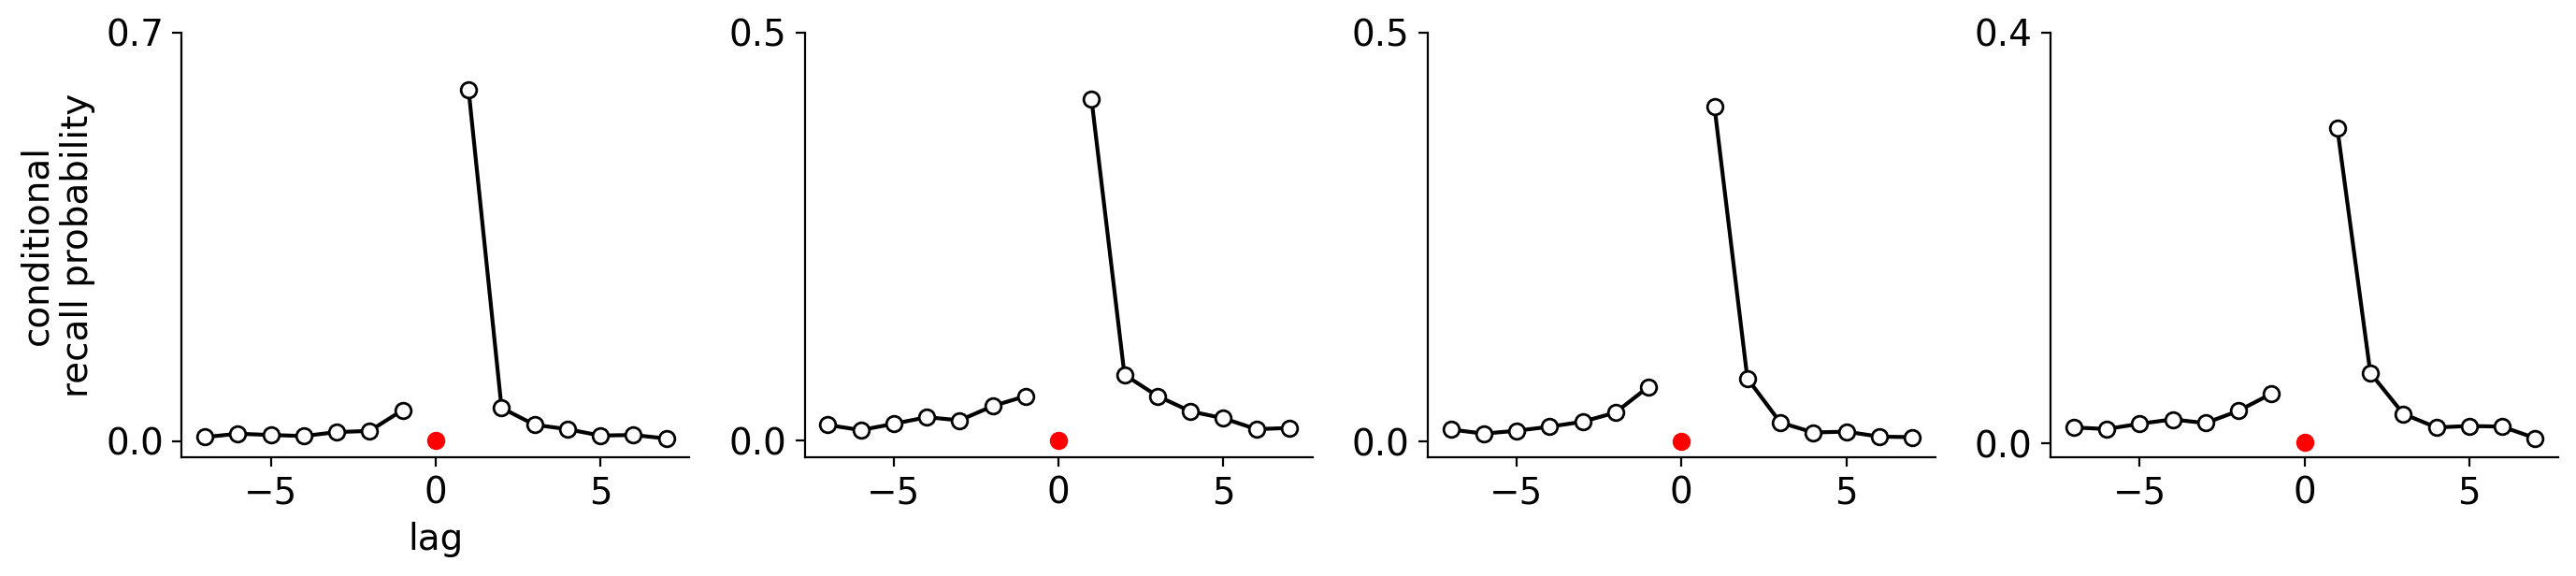

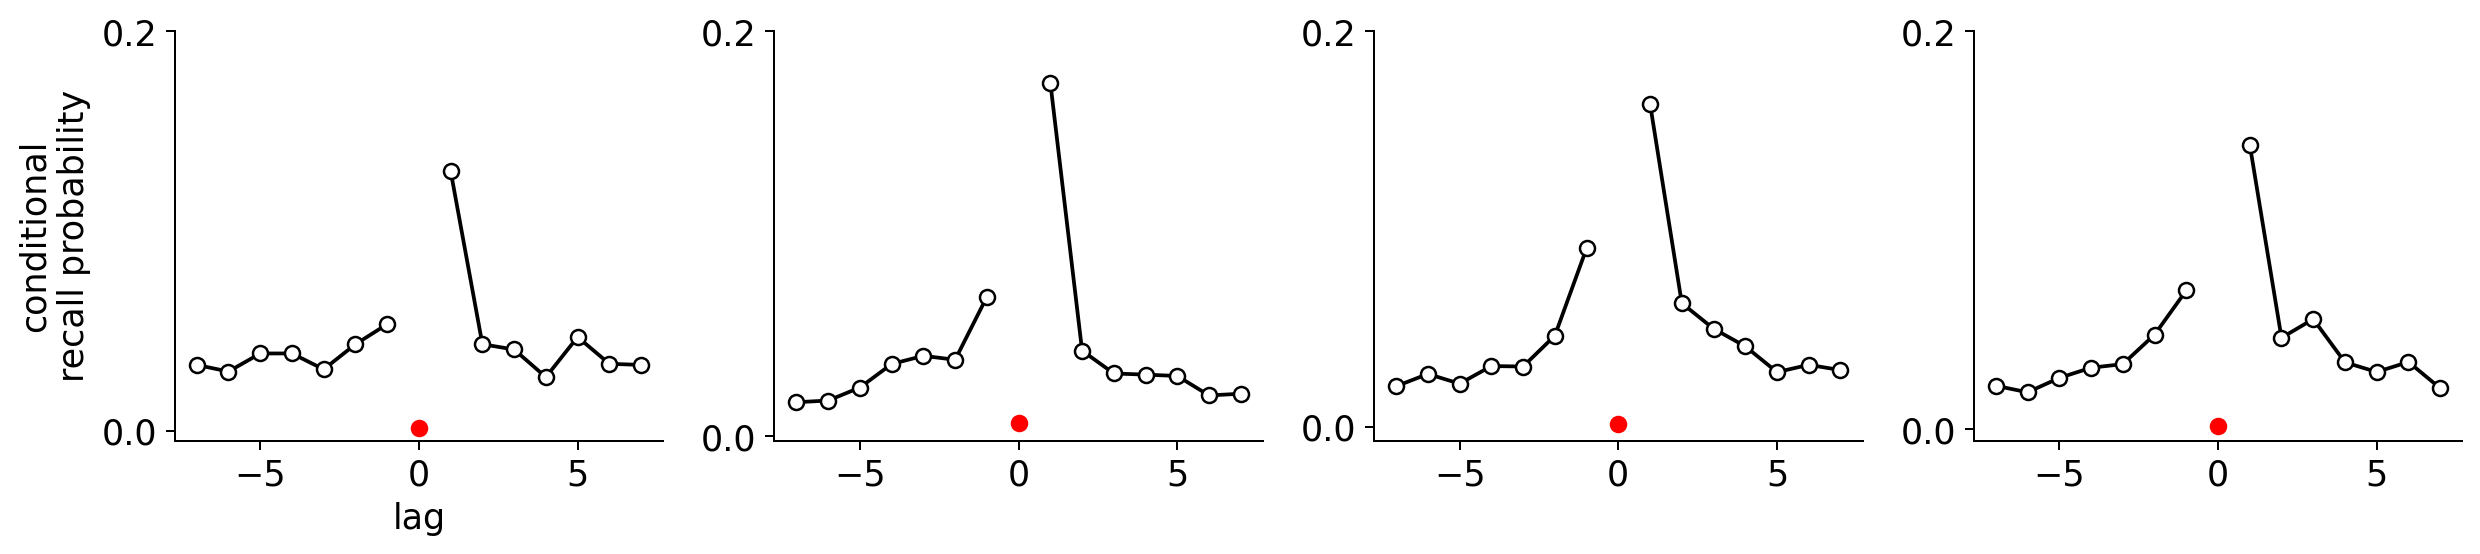

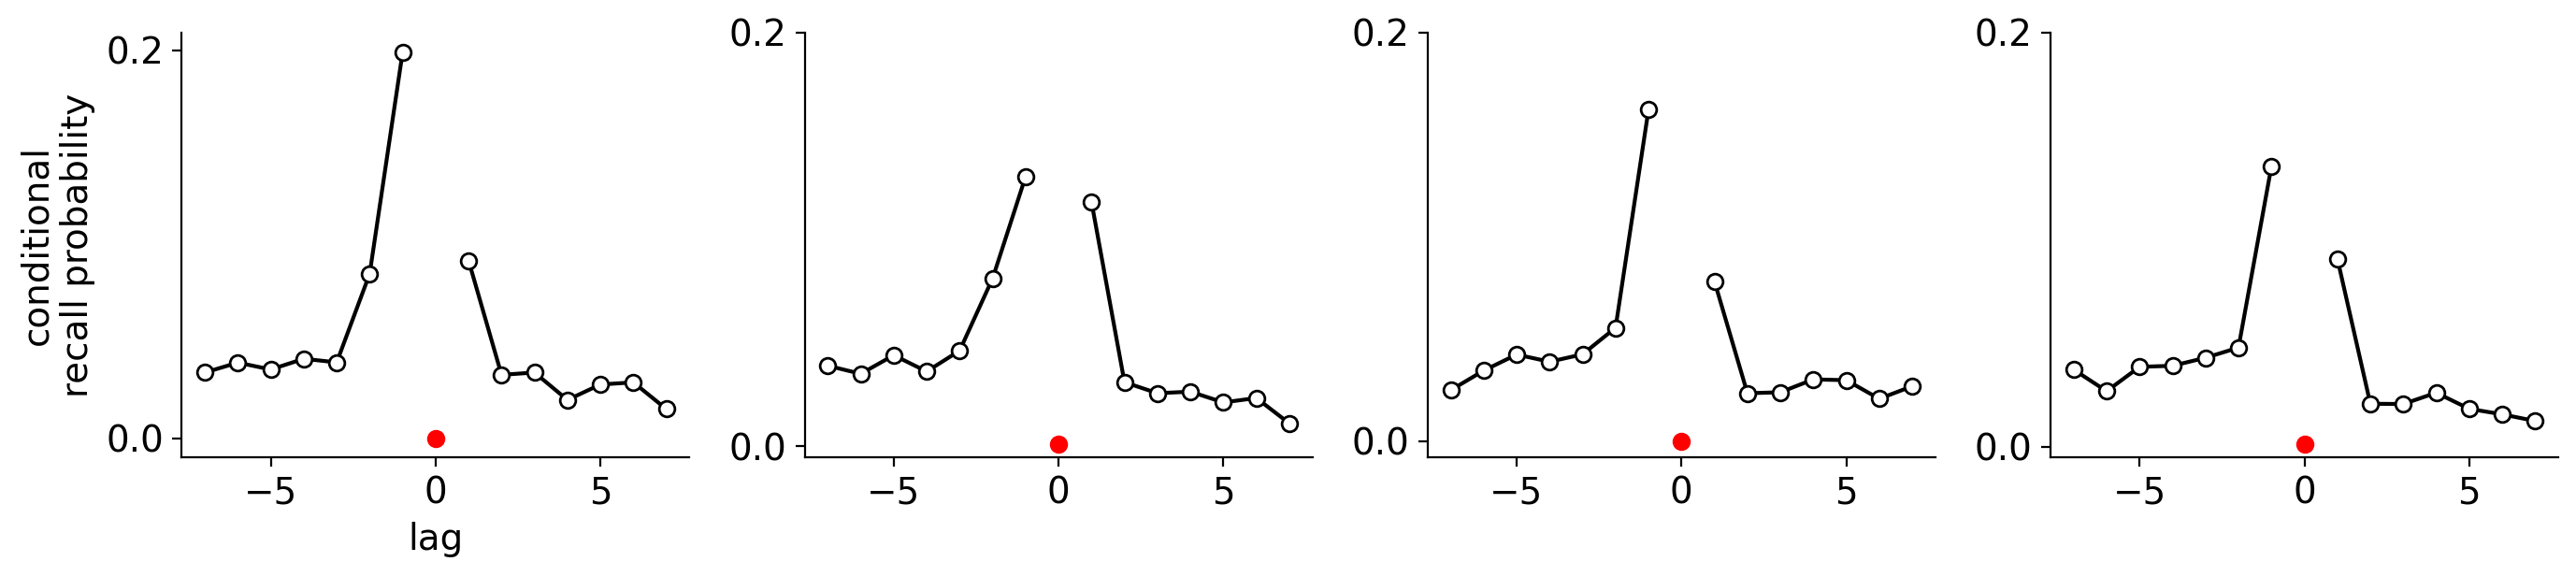

In [61]:
# get the index for sorting forward asymmetry from largest to smallest
sorted_idx = np.argsort(forward_asymmetries)[::-1]


cnt = 0
plt.figure(figsize=(14, 3.3), dpi=200)
for i in sorted_idx:
    midpoint = len(crp_results[i]) // 2
    if forward_asymmetries[i] > 0.68:
        plt.subplot(1, 4, cnt+1)
        plot_crp(crp_results[i], memory_num=8, axis_label=cnt==0)
        cnt += 1
        if cnt == 4:
            break
plt.show()
plt.close()

cnt = 0
plt.figure(figsize=(14, 3.3), dpi=180)
for i in range(len(crp_results)):
    midpoint = len(crp_results[i]) // 2
    # if crp_results[i][midpoint-1] > crp_results[i][midpoint+1]:
    # if forward_asymmetries[i] > 0.7:
    if forward_asymmetries[i] > 0.55 and forward_asymmetries[i] < 0.65 and temporal_factors[i] < 0.7:
        plt.subplot(1, 4, cnt+1)
        plot_crp(crp_results[i], memory_num=8, axis_label=cnt==0)
        cnt += 1
        if cnt == 4:
            break
plt.show()
plt.close()

cnt = 0
plt.figure(figsize=(14, 3.3), dpi=200)
for i in range(len(crp_results)):
    midpoint = len(crp_results[i]) // 2
    if forward_asymmetries[i] < 0.4:
        plt.subplot(1, 4, cnt+1)
        plot_crp(crp_results[i], memory_num=8, axis_label=cnt==0)
        cnt += 1
        if cnt == 4:
            break
plt.show()
plt.close()